In [57]:
import pandas as pd
import numpy as np
from google.colab import drive

In [58]:
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [59]:
data.shape

(32581, 12)

In [60]:
data.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# EDA on Raw Dataa

EDA for Numerical Features (data_num):


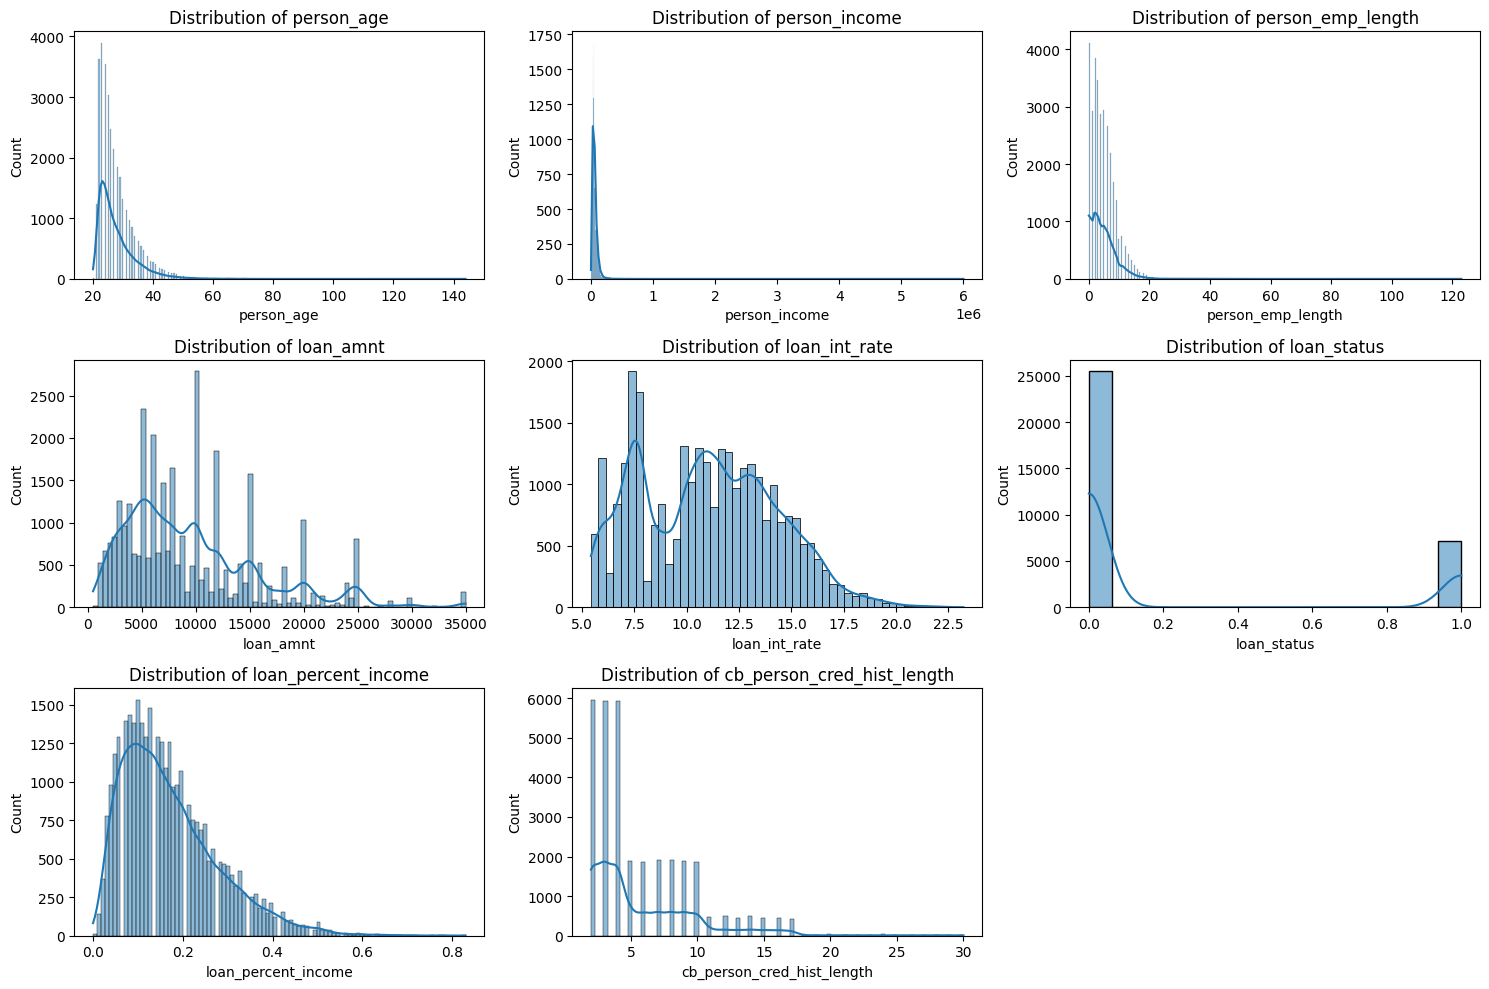

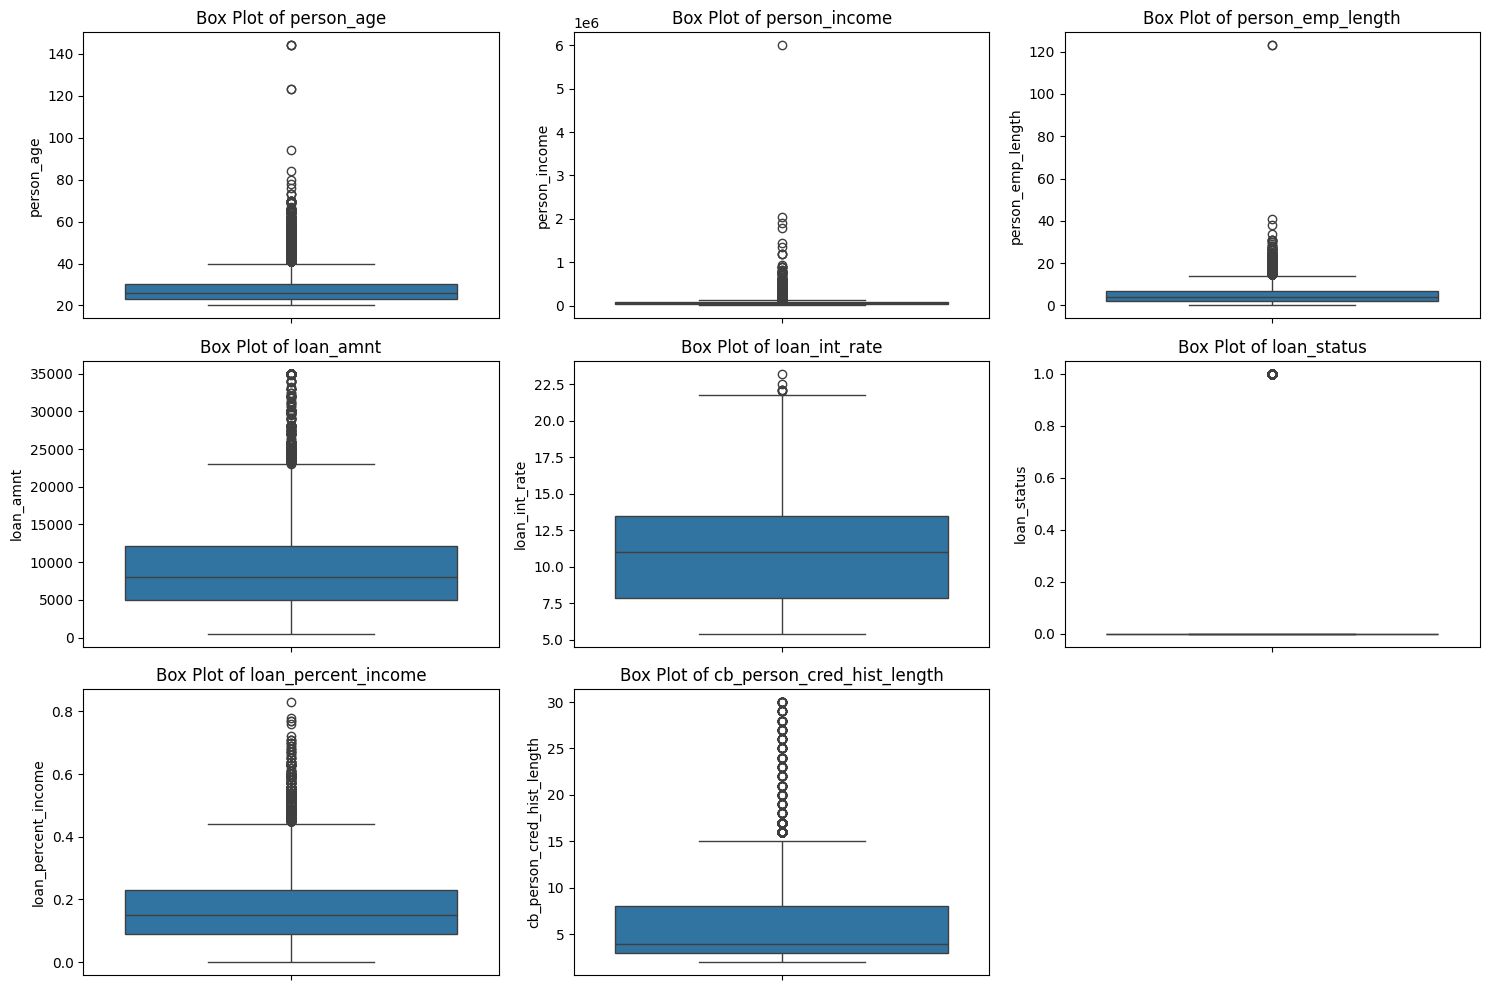

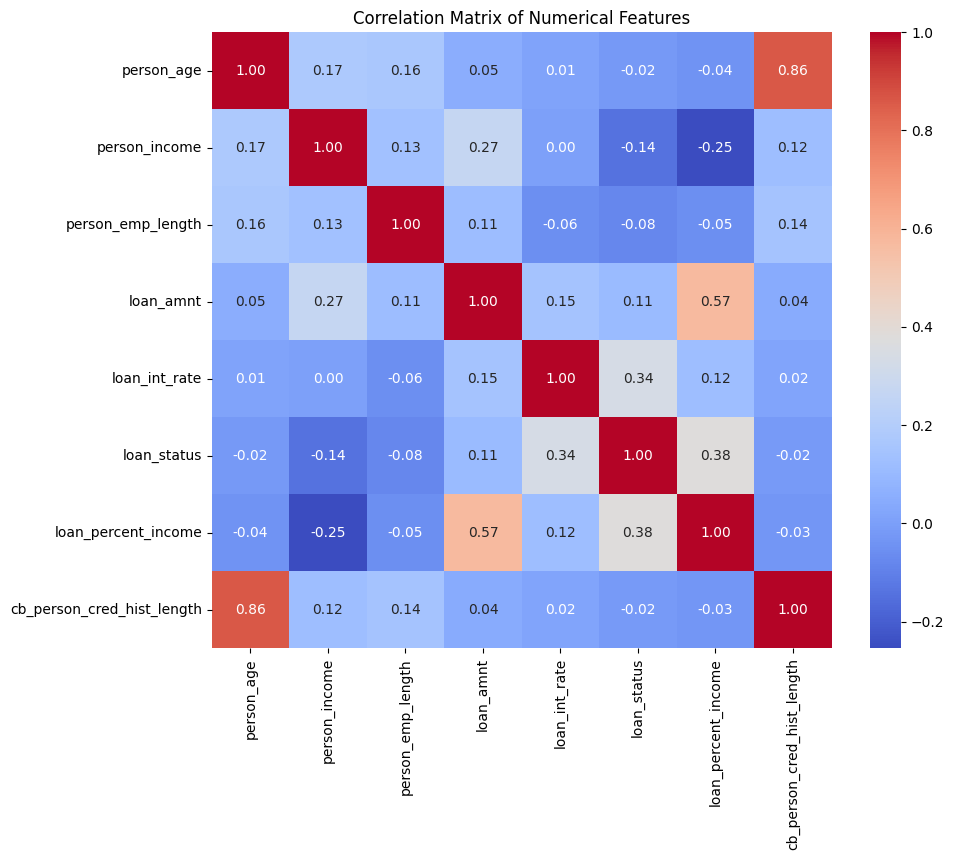


EDA for Categorical Features (data_cat):


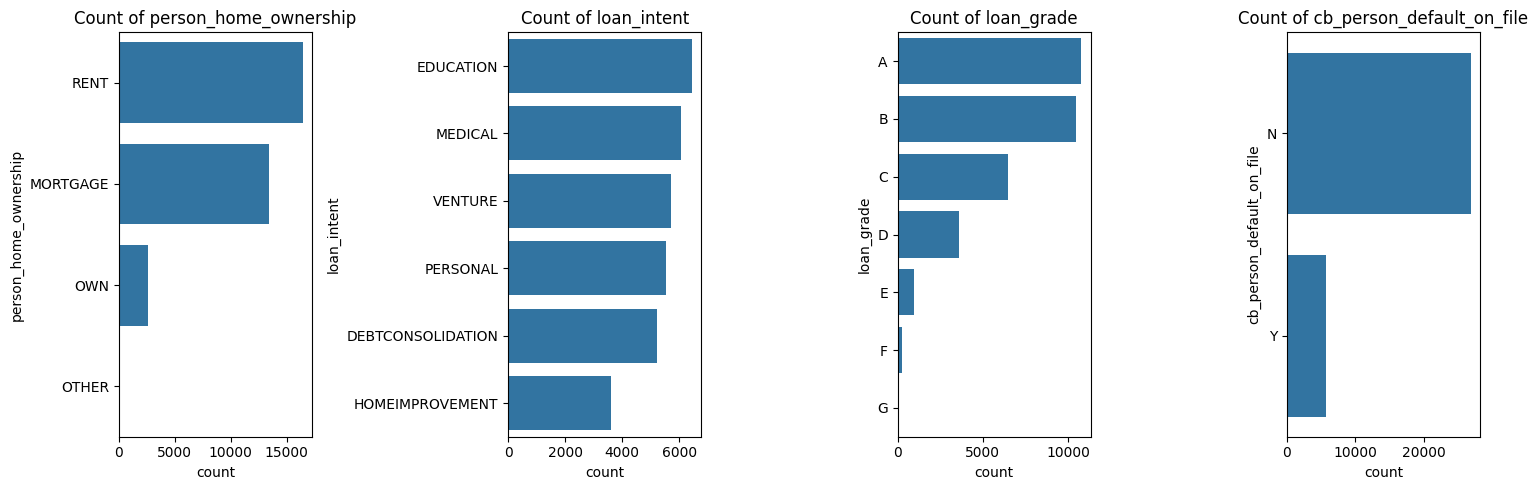

In [62]:
print('EDA for Numerical Features (data_num):')

eda_num = data.select_dtypes(exclude=object)
eda_cat = data.select_dtypes(include=object)

# Histograms for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(eda_num.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(eda_num[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
plt.show()

# Box plots for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(eda_num.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=eda_num[column])
    plt.title(f'Box Plot of {column}')
    plt.tight_layout()
plt.show()

# Correlation Matrix for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(eda_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


print('\nEDA for Categorical Features (data_cat):')
# Count plots for categorical features
plt.figure(figsize=(15, 5))
for i, column in enumerate(eda_cat.columns):
    plt.subplot(1, 4, i + 1) # Adjust subplot grid based on number of columns
    sns.countplot(y=eda_cat[column], order = eda_cat[column].value_counts().index)
    plt.title(f'Count of {column}')
    plt.tight_layout()
plt.show()

# Imputation

In [63]:
data['person_emp_length'].fillna(data['person_emp_length'].mean(), inplace=True)
data['loan_int_rate'].fillna(data['loan_int_rate'].mean(), inplace=True)
data

/tmp/ipykernel_88318/2625540341.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['person_emp_length'].fillna(data['person_emp_length'].mean(), inplace=True)
/tmp/ipykernel_88318/2625540341.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [64]:
data.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


# Target Variable

In [65]:
X = data.drop('loan_status', axis=1)
y = data['loan_status']

# Train-test-split

In [66]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)



In [67]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26064 entries, 21056 to 10353
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  26064 non-null  int64  
 1   person_income               26064 non-null  int64  
 2   person_home_ownership       26064 non-null  object 
 3   person_emp_length           26064 non-null  float64
 4   loan_intent                 26064 non-null  object 
 5   loan_grade                  26064 non-null  object 
 6   loan_amnt                   26064 non-null  int64  
 7   loan_int_rate               26064 non-null  float64
 8   loan_percent_income         26064 non-null  float64
 9   cb_person_default_on_file   26064 non-null  object 
 10  cb_person_cred_hist_length  26064 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 2.4+ MB


In [68]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 32581 entries, 0 to 32580
Series name: loan_status
Non-Null Count  Dtype
--------------  -----
32581 non-null  int64
dtypes: int64(1)
memory usage: 254.7 KB


Training contains target variable while it has been dropped in testing condition, check for potential leaks

In [69]:
X.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32581, 11), (26064, 11), (6517, 11), (26064,), (6517,))

In [70]:
data_num = X.select_dtypes(exclude= object)
data_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_emp_length           32581 non-null  float64
 3   loan_amnt                   32581 non-null  int64  
 4   loan_int_rate               32581 non-null  float64
 5   loan_percent_income         32581 non-null  float64
 6   cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 1.7 MB


In [71]:
data_cat = X.select_dtypes(include= object)
data_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   person_home_ownership      32581 non-null  object
 1   loan_intent                32581 non-null  object
 2   loan_grade                 32581 non-null  object
 3   cb_person_default_on_file  32581 non-null  object
dtypes: object(4)
memory usage: 1018.3+ KB


# Scaling

In [72]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#minmax_scaler = MinMaxScaler()
std_scaler = StandardScaler()

# Apply StandardScaler to selected numerical feature columns
X_train_num = pd.DataFrame(
    std_scaler.fit_transform(X_train[data_num.columns]),
    columns=data_num.columns,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    std_scaler.transform(X_test[data_num.columns]),   # transform only — no fit
    columns=data_num.columns,
    index=X_test.index
)
#end

# One hot Encoding

In [73]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Extract categorical column names from data_cat (which was defined from X)
categorical_cols = data_cat.columns.tolist()

# Fit OneHotEncoder on X_train's categorical features and transform both train and test
X_train_cat_enc = pd.DataFrame(
    ohe.fit_transform(X_train[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_train.index
)

X_test_cat_enc = pd.DataFrame(
    ohe.transform(X_test[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_test.index
)

print("Encoded training categorical features shape:", X_train_cat_enc.shape)
print("Encoded test categorical features shape:", X_test_cat_enc.shape)
X_train_cat_enc.head()

Encoded training categorical features shape: (26064, 15)
Encoded test categorical features shape: (6517, 15)


,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
21056,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5437,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
19859,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
17228,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
X_train = pd.concat([X_train_num, X_train_cat_enc], axis=1)
X_test = pd.concat([X_test_num, X_test_cat_enc], axis=1)

In [75]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(
    sampling_strategy='auto',
    k_neighbors=10,
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train_res).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())

Original data:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Training data:
loan_status
1    20378
0    20378
Name: count, dtype: int64

Testing data:
loan_status
0    5095
1    1422
Name: count, dtype: int64


In [76]:
X_train_res.shape, X_test.shape, y_train_res.shape, y_test.shape

((40756, 22), (6517, 22), (40756,), (6517,))

#PCA Dimension reduction

In [77]:
from sklearn.decomposition import PCA

pca = PCA(n_components=22)

X_train_pca = pd.DataFrame(
    pca.fit_transform(X_train_res)
)
X_test_pca  = pd.DataFrame(
     pca.transform(X_test)
 )

In [78]:
X_test.isna().sum()

,0
person_age,0
person_income,0
person_emp_length,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_cred_hist_length,0
person_home_ownership_OTHER,0
person_home_ownership_OWN,0
person_home_ownership_RENT,0


# Model

In [79]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

models = [
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    DecisionTreeClassifier(max_leaf_nodes=3),
    DecisionTreeClassifier(max_leaf_nodes=10),
    DecisionTreeClassifier(max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1)
]

# Evaluation metrics


RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      5095
           1       0.59      0.69      0.64      1422

    accuracy                           0.83      6517
   macro avg       0.75      0.78      0.76      6517
weighted avg       0.84      0.83      0.83      6517



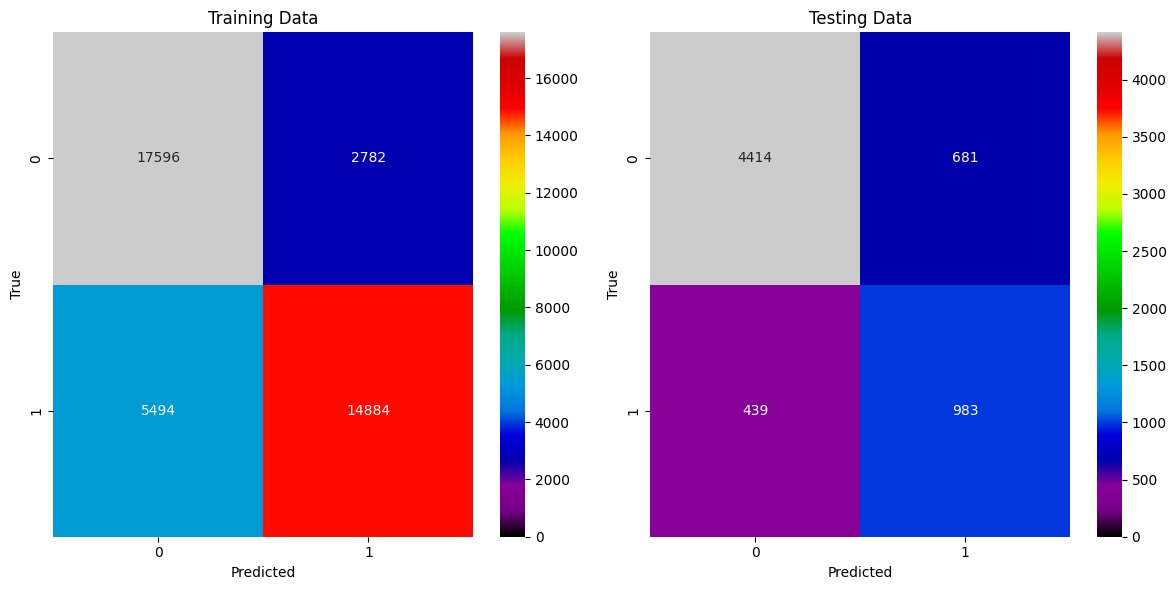


RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      5095
           1       0.66      0.77      0.71      1422

    accuracy                           0.86      6517
   macro avg       0.80      0.83      0.81      6517
weighted avg       0.87      0.86      0.87      6517



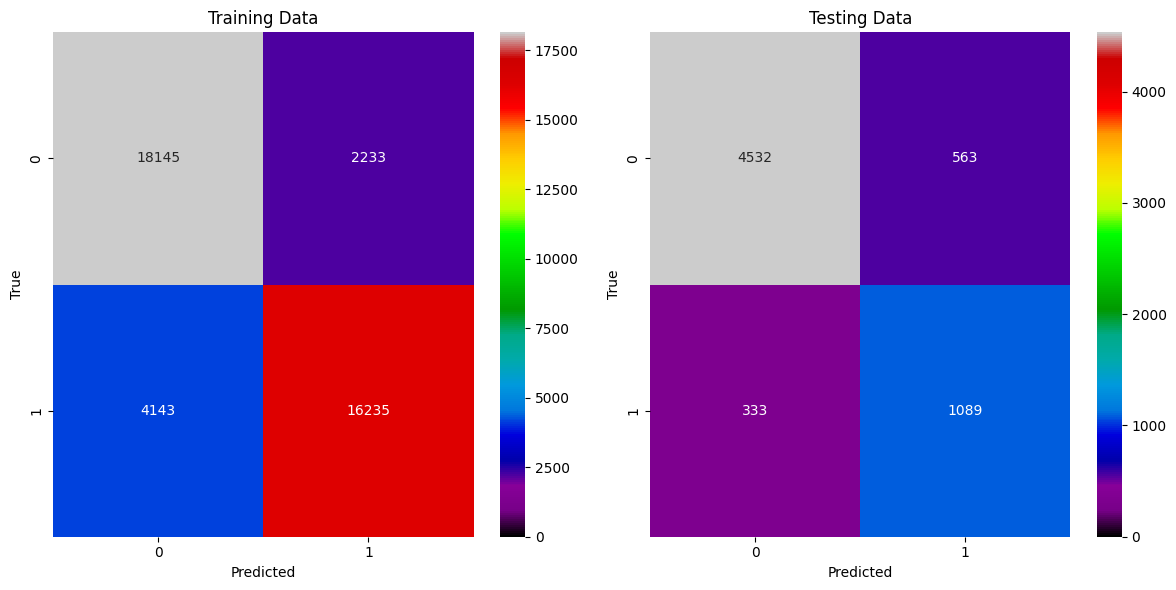


RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      5095
           1       0.71      0.76      0.73      1422

    accuracy                           0.88      6517
   macro avg       0.82      0.84      0.83      6517
weighted avg       0.88      0.88      0.88      6517



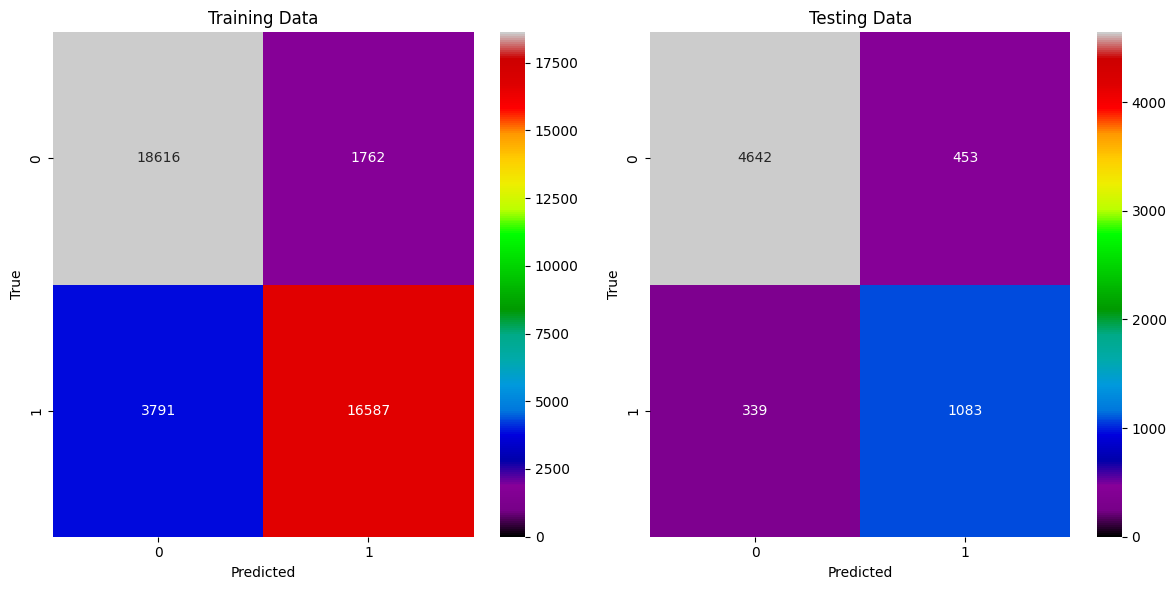


DecisionTreeClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      5095
           1       0.58      0.68      0.62      1422

    accuracy                           0.82      6517
   macro avg       0.74      0.77      0.75      6517
weighted avg       0.83      0.82      0.83      6517



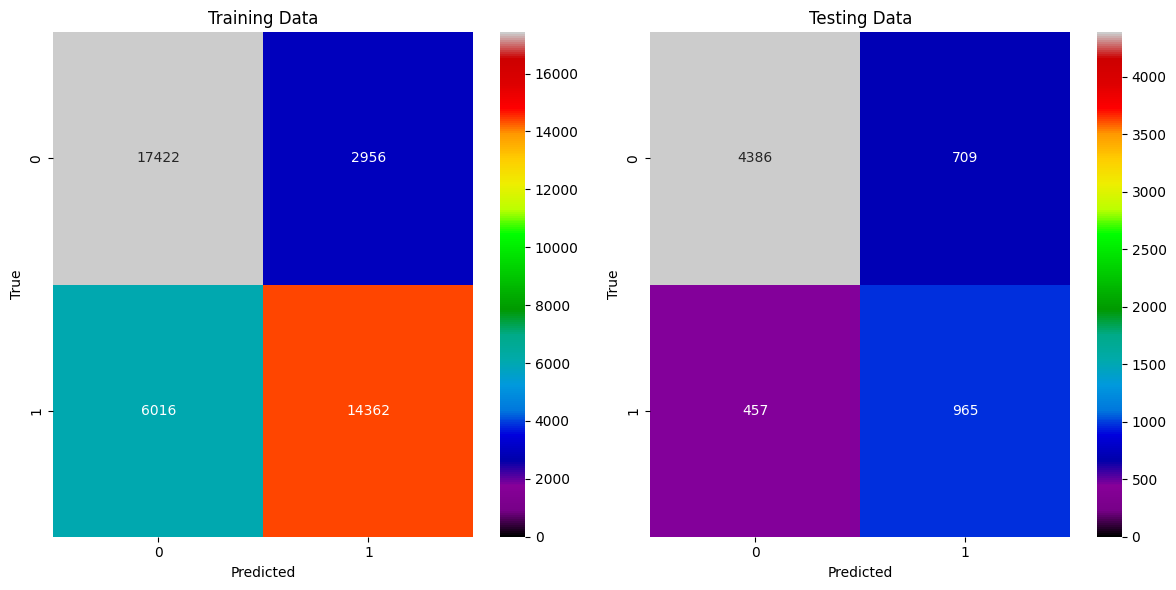


DecisionTreeClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      5095
           1       0.75      0.71      0.73      1422

    accuracy                           0.88      6517
   macro avg       0.83      0.82      0.83      6517
weighted avg       0.88      0.88      0.88      6517



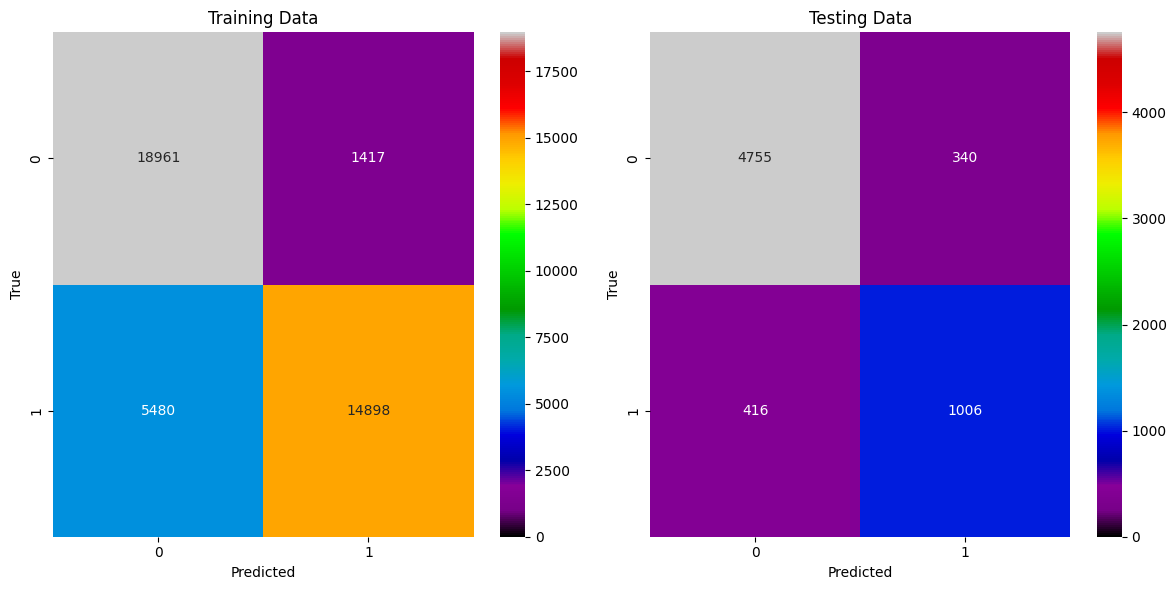


DecisionTreeClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5095
           1       0.87      0.68      0.76      1422

    accuracy                           0.91      6517
   macro avg       0.89      0.83      0.85      6517
weighted avg       0.91      0.91      0.90      6517



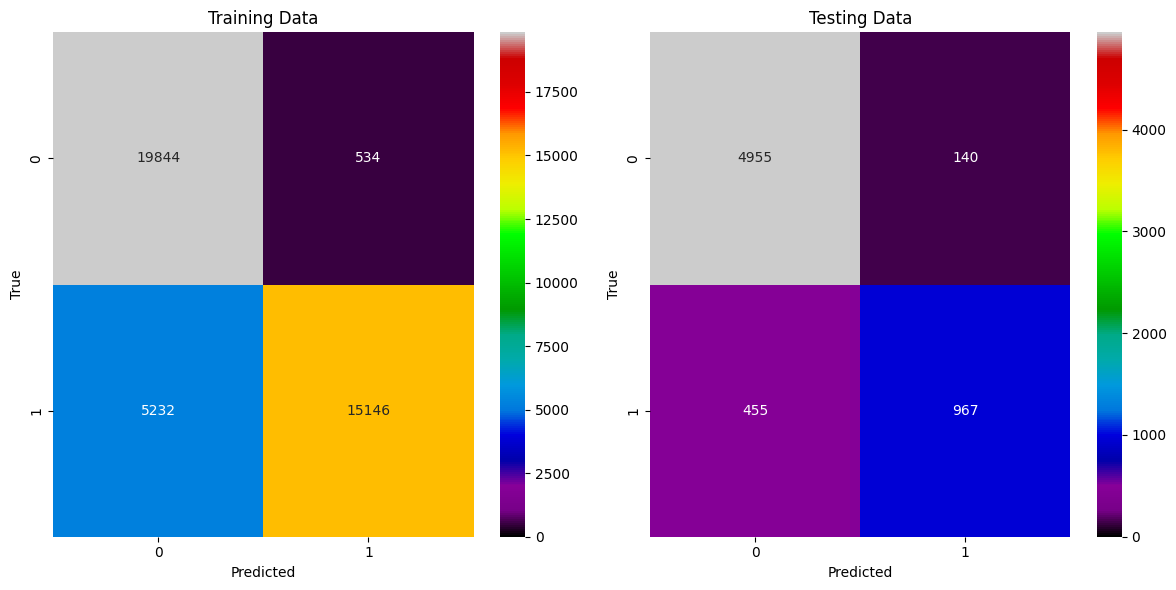


GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      5095
           1       0.70      0.75      0.72      1422

    accuracy                           0.87      6517
   macro avg       0.81      0.83      0.82      6517
weighted avg       0.88      0.87      0.88      6517



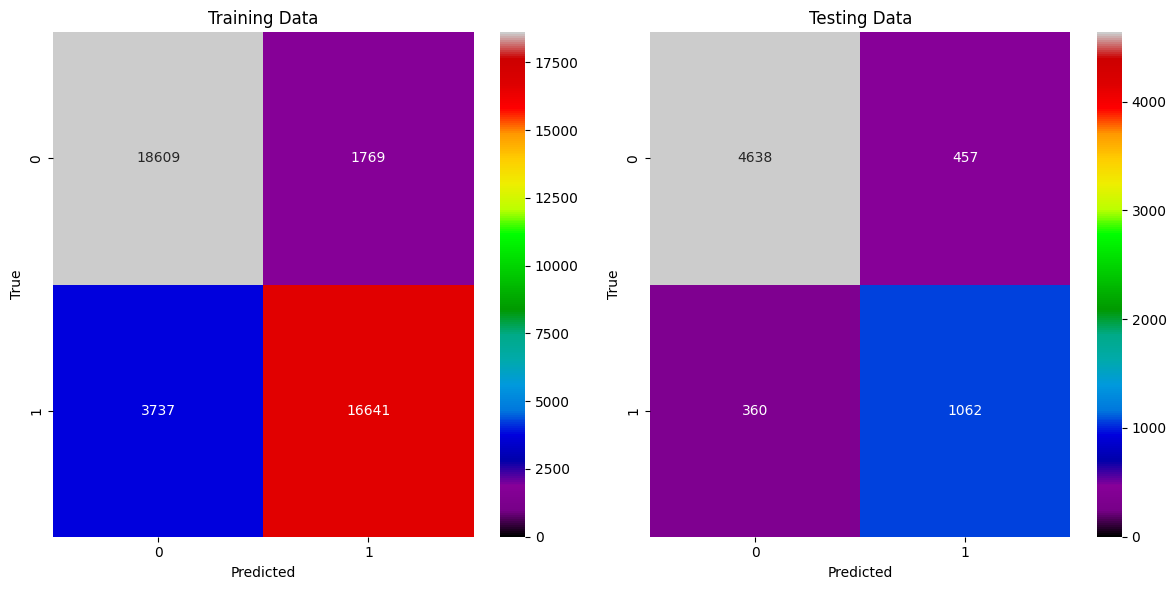


GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      5095
           1       0.81      0.73      0.77      1422

    accuracy                           0.90      6517
   macro avg       0.87      0.84      0.85      6517
weighted avg       0.90      0.90      0.90      6517



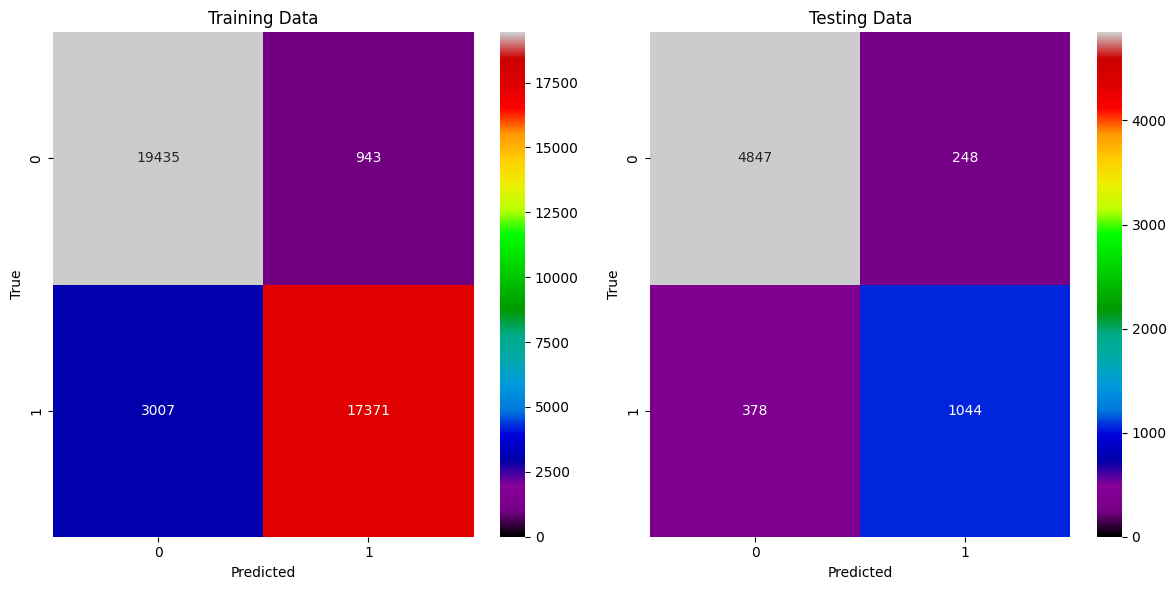


GradientBoostingClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      5095
           1       0.81      0.73      0.77      1422

    accuracy                           0.90      6517
   macro avg       0.87      0.84      0.85      6517
weighted avg       0.90      0.90      0.90      6517



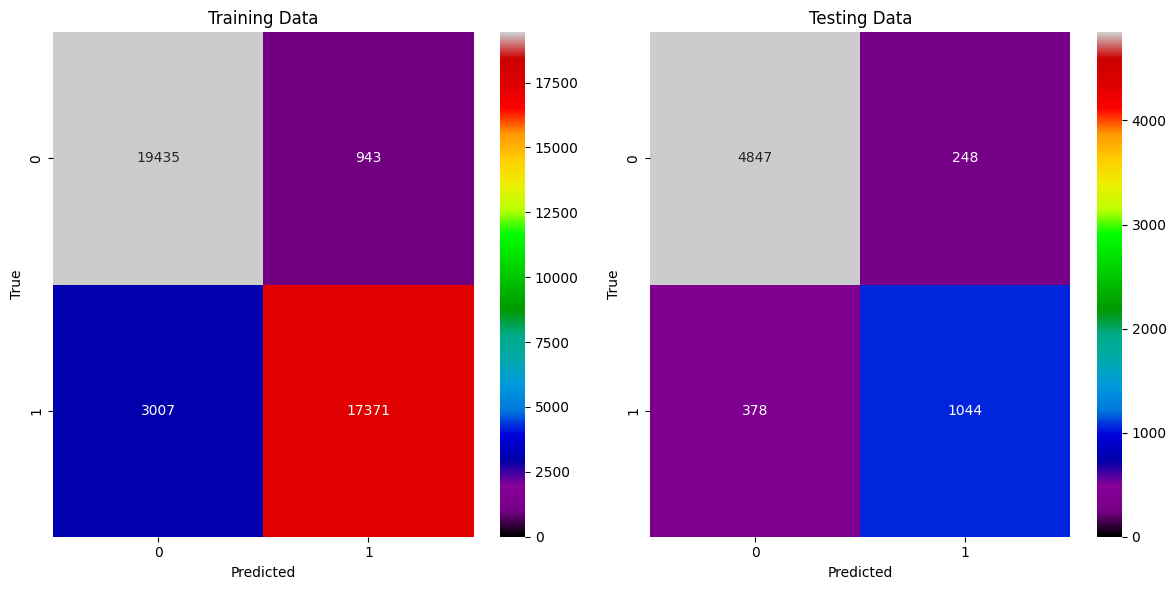

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:41:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=3, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.95      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94     

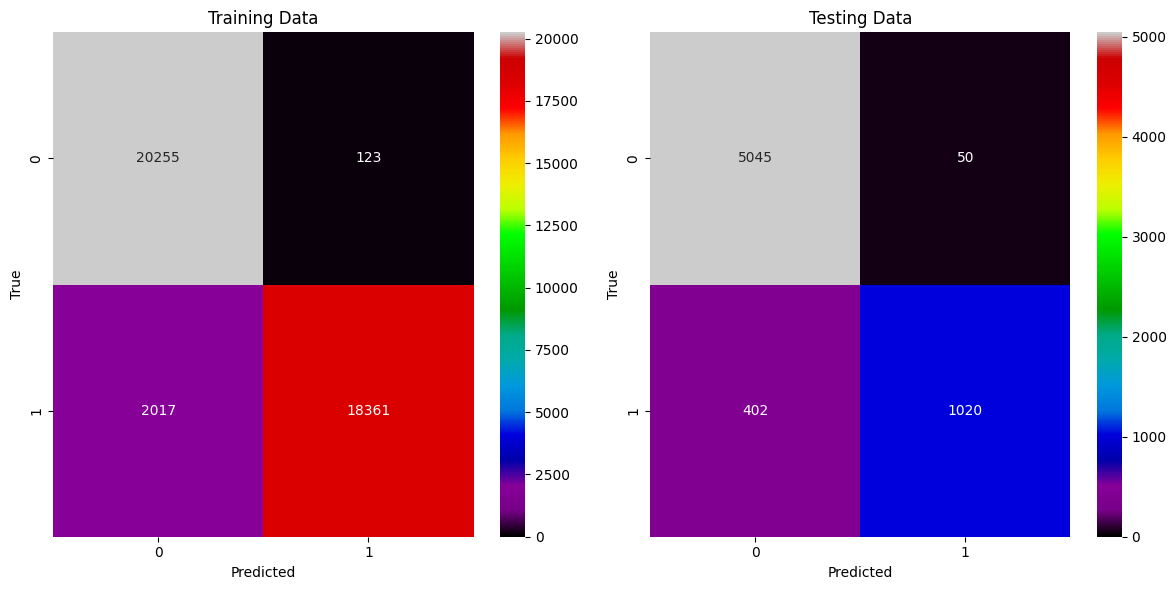

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:41:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=10, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.95      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94    

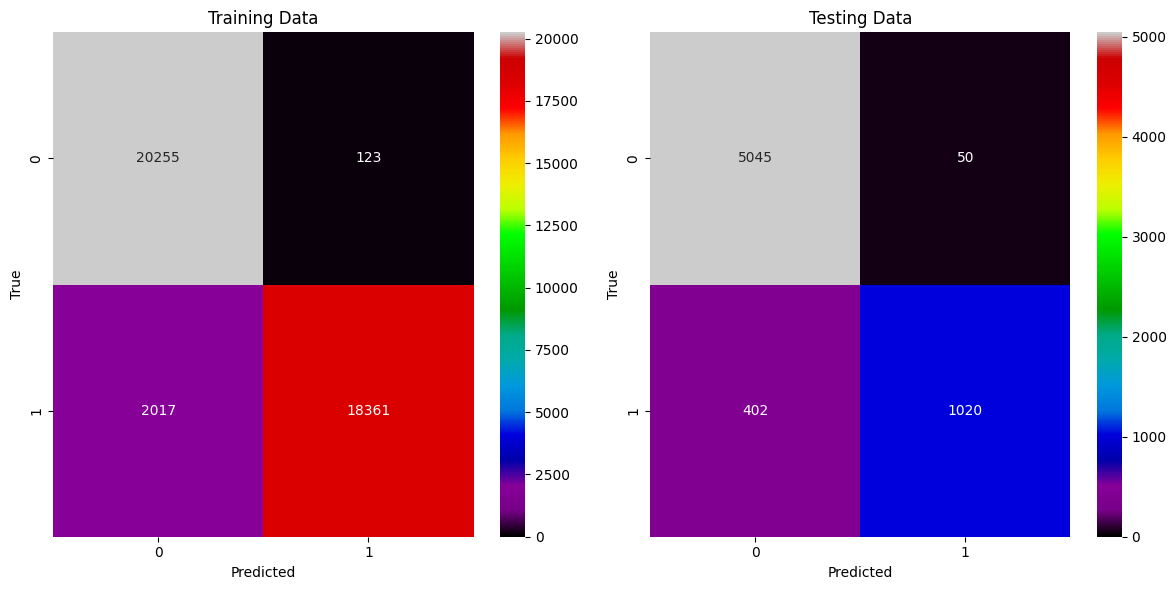

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:41:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=30, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.95      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94    

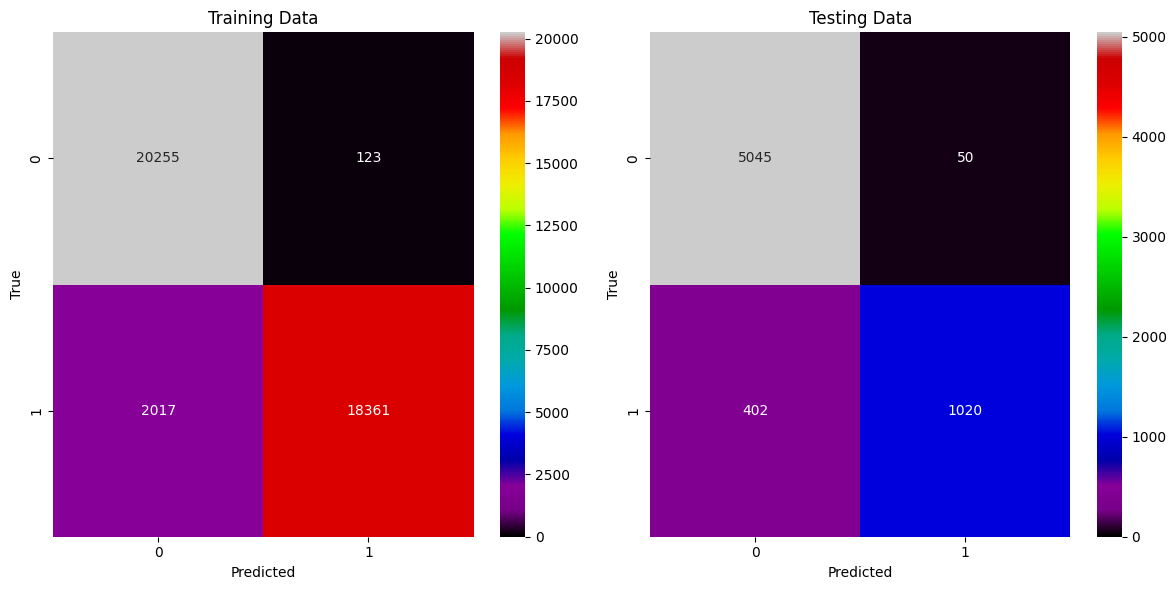


AdaBoostClassifier(learning_rate=0.1, n_estimators=100)
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      5095
           1       0.62      0.65      0.63      1422

    accuracy                           0.84      6517
   macro avg       0.76      0.77      0.76      6517
weighted avg       0.84      0.84      0.84      6517



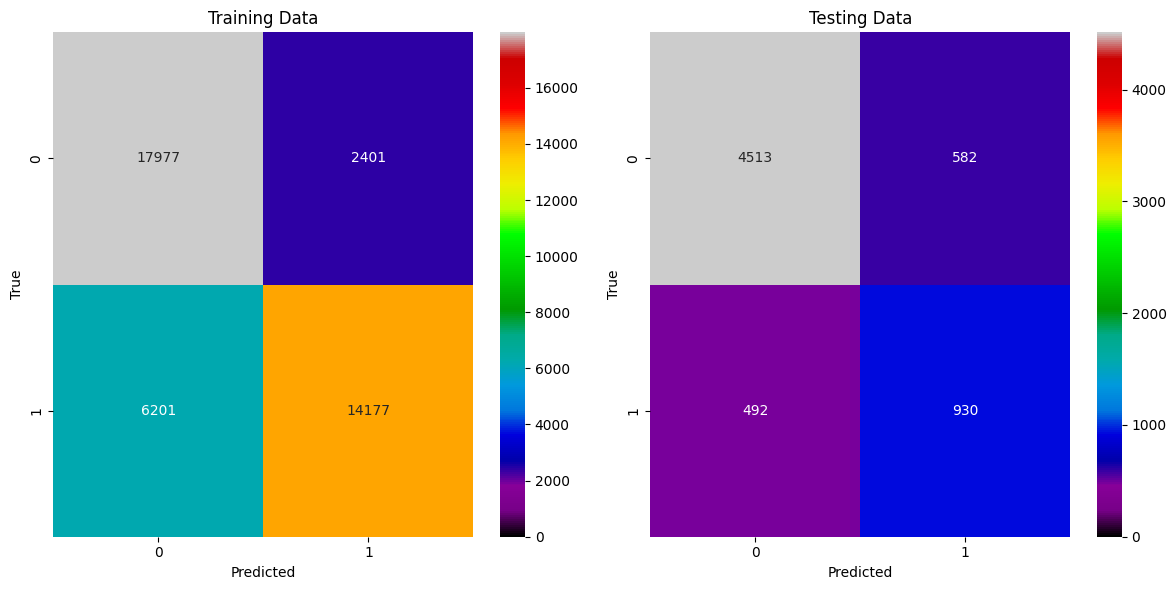


=== Model Comparison (sorted by AUPRC) ===
                                Model    AUPRC    AUROC      MCC       F1
            XGBClassifier(leaves=N/A) 0.873775 0.927801 0.788804 0.818620
            XGBClassifier(leaves=N/A) 0.873775 0.927801 0.788804 0.818620
            XGBClassifier(leaves=N/A) 0.873775 0.927801 0.788804 0.818620
GradientBoostingClassifier(leaves=30) 0.852427 0.918579 0.710160 0.769344
GradientBoostingClassifier(leaves=10) 0.852427 0.918579 0.710160 0.769344
    RandomForestClassifier(leaves=30) 0.828759 0.905349 0.654613 0.732252
 GradientBoostingClassifier(leaves=3) 0.819544 0.903755 0.641952 0.722203
    DecisionTreeClassifier(leaves=30) 0.816730 0.889601 0.717734 0.764729
    RandomForestClassifier(leaves=10) 0.797129 0.890169 0.622201 0.708523
     RandomForestClassifier(leaves=3) 0.736571 0.857923 0.528175 0.637071
    DecisionTreeClassifier(leaves=10) 0.730478 0.861914 0.653705 0.726879
       AdaBoostClassifier(leaves=N/A) 0.716169 0.851856 0.528153 0.6

In [80]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

results = []

for m in models:
    m.fit(X_train_res, y_train_res)
    y_train_pred = m.predict(X_train_res)
    y_test_pred = m.predict(X_test)

    # Calculate y_prob for the current model within the loop
    y_prob = m.predict_proba(X_test)[:, 1]

    auprc = average_precision_score(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    mcc   = matthews_corrcoef(y_test, y_test_pred)
    f1    = f1_score(y_test, y_test_pred)
    name  = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', 'N/A')})"

    results.append({
        'Model': name,
        'AUPRC': auprc,
        'AUROC': auroc,
        'MCC':   mcc,
        'F1':    f1,
    })

    print(f"\n{'='*60}")

    print(m)
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train_res, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0], cmap='nipy_spectral')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1], cmap='nipy_spectral')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()

# ── Model comparison table ────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('AUPRC', ascending=False).reset_index(drop=True)
print("\n=== Model Comparison (sorted by AUPRC) ===")
print(results_df.to_string(index=False))

# ROC and Precision recall curve

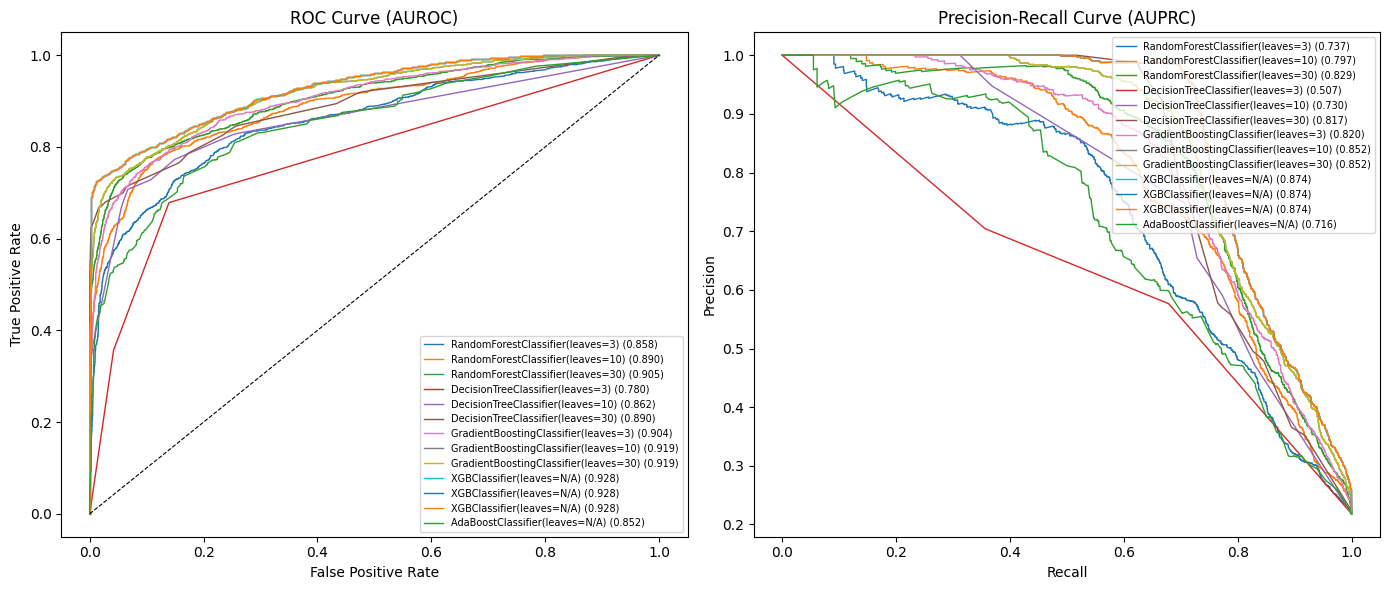

In [81]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, matthews_corrcoef

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for m in models:
    y_prob = m.predict_proba(X_test)[:, 1]
    name = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', 'N/A')})"

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} ({auroc:.3f})", linewidth=1)

    # PR curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall_vals, precision_vals, label=f"{name} ({ap:.3f})", linewidth=1)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve (AUROC)')
axes[0].legend(fontsize=7, loc='lower right')

axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve (AUPRC)')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

In [86]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

model_to_evaluate = models[9] # Change this to select a different model

y_score = model_to_evaluate.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_score)
auroc = roc_auc_score(y_test, y_score)
print("AUPRC:", auprc)
print("AUROC:", auroc)

AUPRC: 0.8737750517661296
AUROC: 0.9278006208342479


# Threshold

Threshold analysis for best model: XGBClassifier(leaves=N/A)
 Threshold  Precision  Recall     F1    MCC
      0.10     0.3515  0.9592 0.5144 0.3915
      0.15     0.4452  0.9114 0.5982 0.4938
      0.20     0.5330  0.8565 0.6571 0.5601
      0.25     0.6303  0.8115 0.7095 0.6236
      0.30     0.7316  0.7841 0.7570 0.6868
      0.35     0.8114  0.7532 0.7812 0.7238
      0.40     0.8774  0.7398 0.8027 0.7578
      0.45     0.9225  0.7278 0.8137 0.7776
      0.50     0.9533  0.7173 0.8186 0.7888
      0.55     0.9672  0.7060 0.8163 0.7894
      0.60     0.9755  0.7011 0.8159 0.7908
      0.65     0.9841  0.6948 0.8145 0.7913
      0.70     0.9859  0.6878 0.8103 0.7876
      0.75     0.9866  0.6751 0.8017 0.7794
      0.80     0.9873  0.6575 0.7894 0.7678


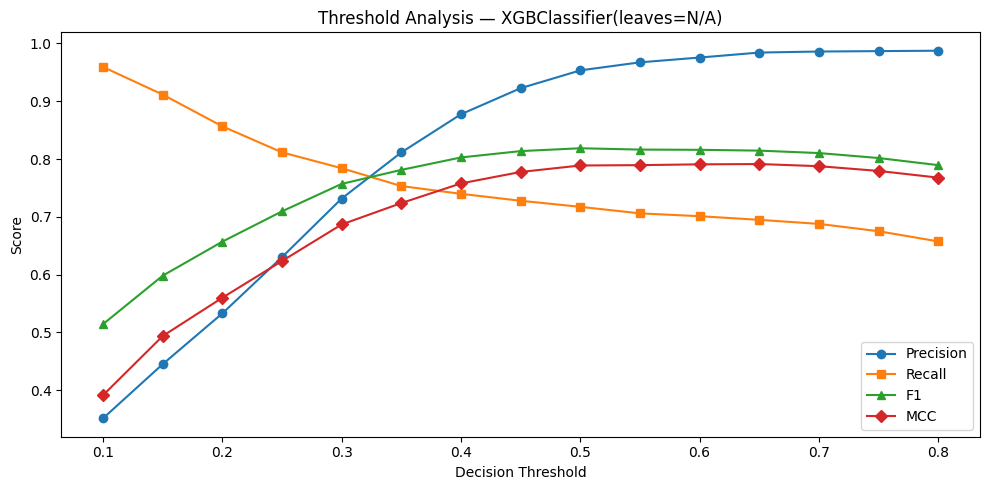

In [83]:
best_model_name = results_df.iloc[0]['Model']
best_model = next(
    m for m in models
    if f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', 'N/A')})" == best_model_name
)

y_prob_best = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.81, 0.05)
threshold_results = []
for t in thresholds:
    preds = (y_prob_best >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, preds), 4),
        'F1':        round(f1_score(y_test, preds, zero_division=0), 4),
        'MCC':       round(matthews_corrcoef(y_test, preds), 4),
    })

thresh_df = pd.DataFrame(threshold_results)
print(f"Threshold analysis for best model: {best_model_name}")
print(thresh_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', marker='o')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    label='Recall',    marker='s')
ax.plot(thresh_df['Threshold'], thresh_df['F1'],        label='F1',        marker='^')
ax.plot(thresh_df['Threshold'], thresh_df['MCC'],       label='MCC',       marker='D')
ax.set(xlabel='Decision Threshold', ylabel='Score', title=f'Threshold Analysis — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

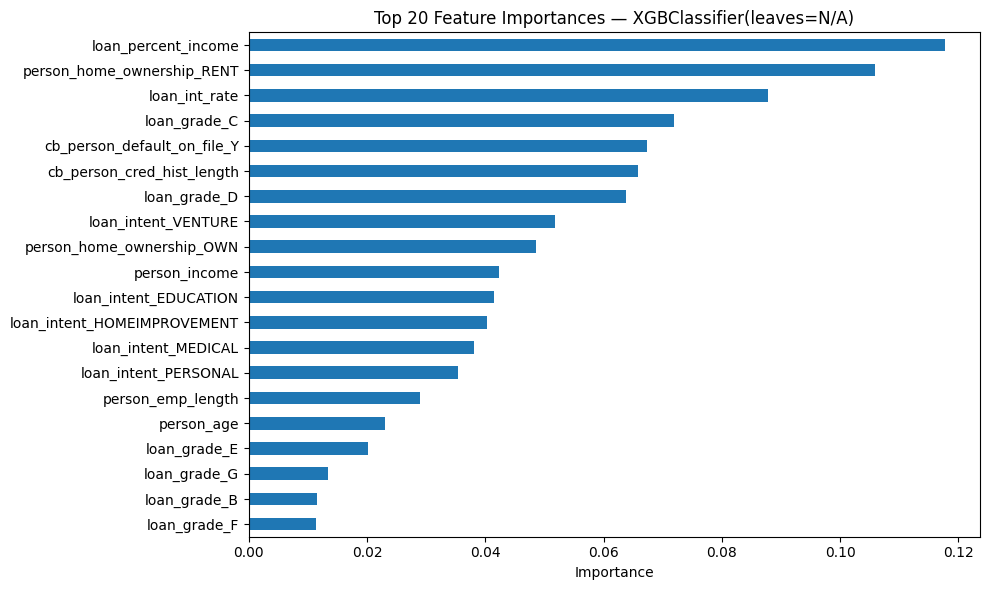

In [84]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feat_imp = feat_imp.nlargest(20).sort_values()

    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh')
    plt.title(f'Top 20 Feature Importances — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_")